# 🚂 TARDIS Project — TRAINING THE PREDICTION MODEL
***

### The Research Team :
* **Raphaël Permentier**
* **Stan Gaumain**
* **Come Chaslerie**

---
### **Our Mission:**

**Now that the dataset is cleaned (see `tardis_eda.ipynb`), we build a regression model that predicts the average arrival delay of a train in minutes.**

---
### **Plan of the notebook:**

* **Step 1 :** Load every library we need
* **Step 2 :** Load the cleaned dataset
* **Step 3 :** Pick the target and the features
* **Step 4 :** Why feature selection matters (small experiment)
* **Step 5 :** Split the data into train and test
* **Step 6 :** Preprocessing pipeline (one-hot encoding for the strings)
* **Step 7 :** Baseline that always predicts the mean
* **Step 8 :** Linear Regression
* **Step 9 :** Decision Tree
* **Step 10 :** Random Forest
* **Step 11 :** Compare the models
* **Step 12 :** Tune the Random Forest with GridSearchCV
* **Step 13 :** Before vs after tuning
* **Step 14 :** Feature importance
* **Step 15 :** Save the best model

---


## 📦 **Step 1 : Load every library we need :**

***

### **Why we need each library :**

* **pandas** : reads the CSV and lets us manipulate the data as a table (DataFrame). It's THE library for tabular data in Python.
* **numpy** : math operations on arrays. We use it for `np.sqrt()` (to compute RMSE from MSE) and `np.sort()` / `np.abs()` later.
* **matplotlib** : the base library for charts. Everything that displays a plot ultimately goes through it.
* **seaborn** : built on top of matplotlib, gives prettier defaults and easy statistical plots (`kdeplot`, `barplot`).
* **joblib** : saves a trained scikit-learn model into a file so we can reload it later (in the dashboard) without retraining.
* **scikit-learn (`sklearn`)** : the main Machine Learning library in Python. Contains everything we need : splits, encoders, models, metrics, hyperparameter search.


In [1]:
# silence sklearn warnings in BOTH the main process AND the joblib workers
# (the env var is inherited by subprocesses, which is what we need for n_jobs=-1)
import os
os.environ["PYTHONWARNINGS"] = "ignore"

import warnings
warnings.filterwarnings("ignore")

# pandas and numpy to manipulate the dataset
import numpy as np
import pandas as pd
# matplotlib and seaborn for the charts
import matplotlib.pyplot as plt
import seaborn as sns
# joblib to save the model into a file
import joblib

# train_test_split = split the data, GridSearchCV = hyperparameter tuning
from sklearn.model_selection import train_test_split, GridSearchCV
from joblib import parallel_config  # to switch joblib backend to threading
# ColumnTransformer = apply different transformation on different columns
from sklearn.compose import ColumnTransformer
# OneHotEncoder = transform string columns into 0/1 columns
from sklearn.preprocessing import OneHotEncoder
# Pipeline = chain preprocessing + model in one object
from sklearn.pipeline import Pipeline
# DummyRegressor = baseline model that always predict the mean
from sklearn.dummy import DummyRegressor
# the two real models we use
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
# the three regression metrics : MAE, MSE (for RMSE) and R2
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# nicer default style for seaborn plots
sns.set_theme(style="whitegrid")


## 📂 **Step 2 : Load the cleaned dataset :**

***

### **Why we load the cleaned CSV and not the raw one :**

**The raw `dataset.csv` has missing values, wrong types, duplicates, weird outliers, etc. Trying to train a model on it would either crash, or worse, train silently on garbage and give nonsense predictions.**

**`tardis_eda.ipynb` already did all the cleaning : it fixed the types, removed duplicates, dropped impossible values (negative delays, journeys under 1 minute, etc.), filled the missing values, and added a few useful columns (`Month`, `Year`, `semester`). We just have to read the result.**

**This separation between cleaning and modeling is a standard practice : it keeps the model notebook focused on ML, and makes the cleaning steps reusable.**


In [2]:
# read the CSV produced by tardis_eda.ipynb into a pandas DataFrame
df = pd.read_csv("cleaned_dataset.csv")
# print the shape (rows, columns) so we know how much data we have
print("Shape :", df.shape)
# show the first 5 rows to confirm everything looks good after loading
df.head()


Shape : (10464, 28)


,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,...,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)",Month,Year,semester,delay_category,route
0,2018-01,NATIONAL,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.00,870.0,5.0,289.0,11.247809,3.693179,...,31.092437,10.924370,15.966387,5.040000,0.840336,1,2018,1,7.0,BORDEAUX ST JEAN-PARIS MONTPARNASSE
1,2018-01,NATIONAL,LE MANS,PARIS MONTPARNASSE,56.00,406.0,1.0,213.0,8.479969,4.567119,...,35.000000,16.666667,16.666667,8.333333,3.333333,1,2018,1,5.0,LE MANS-PARIS MONTPARNASSE
2,2018-01,NATIONAL,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.0,0.0,21.0,6.239683,0.286283,...,27.777778,16.666667,16.666667,5.555556,11.111111,1,2018,1,3.0,PARIS MONTPARNASSE-LA ROCHELLE VILLE
3,2018-01,NATIONAL,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,71.0,7.235211,0.980000,...,22.222222,16.666667,20.370370,5.555556,1.851852,1,2018,1,5.0,PARIS MONTPARNASSE-NANTES
4,2018-01,NATIONAL,POITIERS,PARIS MONTPARNASSE,94.00,472.0,4.0,224.0,6.784673,3.229701,...,45.614035,0.000000,15.789474,1.754386,1.754386,1,2018,1,5.0,POITIERS-PARIS MONTPARNASSE


**The dataset has 10464 rows and 28 columns. Every row is one (departure station / arrival station / month) combination, and the columns describe the trains for that combination.**


## 🎯 **Step 3 : Pick the target and the features :**

***

### **What is the difference between target and features ?**

**In supervised learning we always have two things :**

* **The target (`y`) :** the thing we want to predict. There is only ONE target column.
* **The features (`X`) :** all the information the model is allowed to look at to make its prediction. There can be many feature columns.

**The model learns a function `f` such that `f(X) ≈ y`. In our case `f` will try to estimate the average arrival delay from journey characteristics.**

***

### **Our Target :**

**We predict `Average delay of all trains at arrival`. It is a continuous number in minutes (not a category), so we are doing a *regression* problem (and not a *classification*).**

### **Our Features :**

**We use the journey characteristics that we can know *before* the trip happens :**

* **`Service`** : National or International
* **`Departure station`** and **`Arrival station`**
* **`Route`** : combination of departure + arrival, captures the typical delay of a whole line in a single column
* **`Average journey time`** : how long the trip is supposed to last
* **`Number of scheduled trains`** : how busy the line is
* **`Month`**, **`Year`** and **`semester`** : temporal features added during the EDA (some months are worse than others, for example winter strikes)


In [3]:
# the column we want to predict
TARGET = "Average delay of all trains at arrival"

# Service has some NaN -> we fill them with the most frequent value
df["Service"] = df["Service"].fillna(df["Service"].mode()[0])

# create a new combined feature : the route (Departure - Arrival)
# captures the typical delay of a whole line in a single column
df["Route"] = df["Departure station"] + " - " + df["Arrival station"]

# categorical columns (strings) -> we will one-hot encode them
FEATURES_CAT = ["Service", "Departure station", "Arrival station", "Route"]

# numeric columns -> we can use them directly
FEATURES_NUM = ["Average journey time", "Number of scheduled trains", "Month", "Year", "semester"]

# final list of features used by the model
FEATURES = FEATURES_CAT + FEATURES_NUM

# copy the columns we need so we don't touch the original df
data = df[FEATURES + [TARGET]].copy()

# show the shape after filtering
print("Shape :", data.shape)
data.head()


Shape : (10464, 10)


,Service,Departure station,Arrival station,Route,Average journey time,Number of scheduled trains,Month,Year,semester,Average delay of all trains at arrival
0,NATIONAL,BORDEAUX ST JEAN,PARIS MONTPARNASSE,BORDEAUX ST JEAN - PARIS MONTPARNASSE,141.00,870.0,1,2018,1,6.511118
1,NATIONAL,LE MANS,PARIS MONTPARNASSE,LE MANS - PARIS MONTPARNASSE,56.00,406.0,1,2018,1,5.363539
2,NATIONAL,PARIS MONTPARNASSE,LA ROCHELLE VILLE,PARIS MONTPARNASSE - LA ROCHELLE VILLE,166.00,226.0,1,2018,1,2.938053
3,NATIONAL,PARIS MONTPARNASSE,NANTES,PARIS MONTPARNASSE - NANTES,216.21,508.0,1,2018,1,5.292211
4,NATIONAL,POITIERS,PARIS MONTPARNASSE,POITIERS - PARIS MONTPARNASSE,94.00,472.0,1,2018,1,4.882372


### 📊 **Quick look at the target distribution :**

**Before training anything we look at how the delays are spread. This will help us understand what error size is reasonable.**


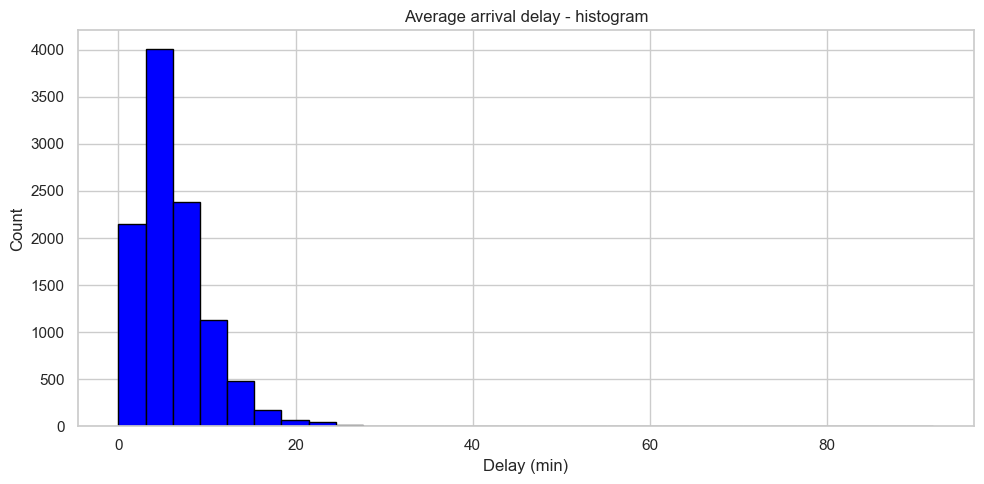

count    10464.000000
mean         6.194069
std          4.178708
min          0.000000
25%          3.408213
50%          5.364412
75%          8.110263
max         92.000000
Name: Average delay of all trains at arrival, dtype: float64

In [4]:
# draw the histogram of the delays
plt.figure(figsize=(10, 5))
plt.hist(data[TARGET], bins=30, color="blue", edgecolor="black")
# add a title and labels
plt.title("Average arrival delay - histogram")
plt.xlabel("Delay (min)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# basic numeric stats : mean, std, min, quartiles, max
data[TARGET].describe()


**Result:** Most delays are small (a few minutes) but there are some bigger outliers. This matters later when we read the RMSE because RMSE is more sensitive to big errors than MAE.


## 🔬 **Step 4 : Why feature selection matters :**

***

### **Our Strategy :**

**Before going into the actual training, we do a small experiment to show why we chose our features. We compare three different feature sets using the same Random Forest model, and look at the scores :**

1. **Minimal :** only 2 numeric features (`Average journey time`, `Number of scheduled trains`)
2. **Our features :** the 9 features we chose
3. **Naive setup :** our 9 features PLUS some "delay at departure" columns

**Spoiler : the third one will look amazing but it actually cheats. Those extra columns describe what happens during the trip, not before, so the model gets to peek at part of the answer. This is called *data leakage* and it is the classic beginner mistake to avoid.**


In [5]:
# Random Forest used for every variant so the comparison is fair
def evaluate_features(name, cat_cols, num_cols):
    # build a small preprocessor for this feature set
    parts = []
    if cat_cols:
        parts.append(("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols))
    if num_cols:
        parts.append(("num", "passthrough", num_cols))
    pp = ColumnTransformer(parts)

    # always the same Random Forest, so the only thing that changes is the features
    m = Pipeline([
        ("prep", pp),
        ("model", RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)),
    ])

    # rebuild X with exactly the columns of this variant
    X_var = df[cat_cols + num_cols]
    X_tr, X_te, y_tr, y_te = train_test_split(X_var, df[TARGET], test_size=0.2, random_state=42)
    m.fit(X_tr, y_tr)
    p = m.predict(X_te)
    return {
        "Setup": name,
        "MAE": mean_absolute_error(y_te, p),
        "R2": r2_score(y_te, p),
    }


# 3 variants : few features, our features, our features + leaky columns
feature_scores = [
    evaluate_features(
        "1. Minimal (2 features)",
        cat_cols=[],
        num_cols=["Average journey time", "Number of scheduled trains"],
    ),
    evaluate_features(
        "2. Our features (9)",
        cat_cols=FEATURES_CAT,
        num_cols=FEATURES_NUM,
    ),
    evaluate_features(
        "3. Naive + leaky columns",
        cat_cols=FEATURES_CAT,
        num_cols=FEATURES_NUM + [
            "Number of trains delayed at departure",
            "Average delay of all trains at departure",
            "Number of trains delayed > 15min",
            "Number of trains delayed > 30min",
        ],
    ),
]

feature_scores_df = pd.DataFrame(feature_scores).set_index("Setup")
feature_scores_df


,MAE,R2
Setup,,
1. Minimal (2 features),2.671315,0.152789
2. Our features (9),2.135830,0.396272
3. Naive + leaky columns,1.300420,0.695273


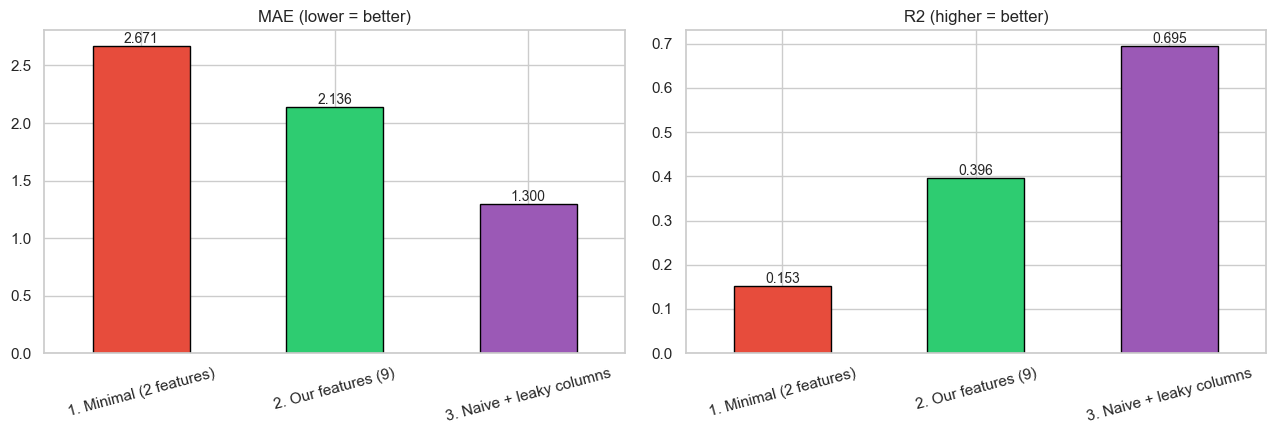

In [6]:
# bar chart to visualize the gap between the three setups
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# MAE : lower is better
feature_scores_df["MAE"].plot(kind="bar", ax=axes[0],
    color=["#e74c3c", "#2ecc71", "#9b59b6"],
    title="MAE (lower = better)", edgecolor="black")

# R2 : higher is better
feature_scores_df["R2"].plot(kind="bar", ax=axes[1],
    color=["#e74c3c", "#2ecc71", "#9b59b6"],
    title="R2 (higher = better)", edgecolor="black")

# write the value on top of each bar
for ax in axes:
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha="center", va="bottom", fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


**Result:**

* **Setup 1 (minimal)** has a low R2 - 2 features are not enough, the model barely beats the baseline.
* **Setup 2 (our features)** is the realistic best : a clear jump because we added the categorical info (stations, route, service) and the temporal columns.
* **Setup 3 (with leakage)** looks like a huge improvement but it is a trap. The added columns (`Average delay of all trains at departure`, etc.) are not really inputs : they are computed from the same trip we are trying to predict. In real life we would not have this information *before* the train arrives, so the model would be useless in production.

**Conclusion : we keep Setup 2 (our 9 honest features) for the rest of the notebook.**


## ✂️ **Step 5 : Split the data into train and test :**

***

### **Why we do not train and test on the same data :**

**If we evaluate a model on the same data it was trained on, the score will look amazing but it does not mean the model is good. The model could just be memorizing the training set (this is called *overfitting*). What we really want to know is : how well does the model perform on data it has never seen ?**

**To measure that, we split the dataset into two parts :**

* **Training set (80%)** : the model learns from this part. It can see the features AND the target.
* **Test set (20%)** : the model never sees this part during training. We use it once, at the end, to measure the real performance.

### **Why we fix the `random_state` :**

**`train_test_split` shuffles the rows randomly before splitting. If we don't fix the seed (`random_state=42`), each run produces a different split, so the scores will fluctuate. With a fixed seed, the split is reproducible and every model is evaluated on the EXACT same test set, which makes the comparison fair.**

### **Why 80/20 :**

**Standard practice. The training set has to be big enough for the model to learn, and the test set has to be big enough for the score to be statistically meaningful. 80/20 is the usual sweet spot for datasets with thousands of rows.**


In [7]:
# X = the features the model is allowed to look at
X = data[FEATURES]
# y = the target we want the model to predict
y = data[TARGET]

# split 80% train / 20% test with a fixed seed for reproducibility.
# the SAME random_state is reused everywhere -> every model is evaluated on the
# exact same test set, which makes the comparison fair.
X_training, X_test, y_training, y_test = train_test_split(
    X, y,
    test_size=0.2,             # 20% of the rows for the test set
    random_state=42,           # fixed seed -> same split at every run
)

# print the shapes to be sure the split worked
print("Train :", X_training.shape, " Test :", X_test.shape)


Train : (8371, 9)  Test : (2093, 9)


## ⚙️ **Step 6 : Preprocessing pipeline :**

***

### **The Problem :**

**Scikit-learn models only understand numbers. But `Service`, `Departure station`, `Arrival station` and `Route` are strings (`"PARIS MONTPARNASSE"`, `"LE MANS"`, etc.). If we send these directly to a `LinearRegression`, it will crash.**

### **Our Fix : one-hot encoding**

**One-hot encoding turns each string column into several 0/1 columns, one per unique value. Example with the `Service` column :**

```
Before (1 column with strings)        After (2 columns with 0/1)
Service                               Service_National   Service_International
National                       →      1                  0
International                         0                  1
National                              1                  0
```

**Each row gets a `1` in exactly one column and `0` in the others. The model can now treat each station / service as a separate binary input. With 200 stations we get 200 columns, but it works.**

### **Why a `ColumnTransformer` :**

**Some columns need one-hot encoding (the strings), some don't (the numerics). The `ColumnTransformer` lets us apply different transformations to different columns and then concatenates the result. Wrapping all of this in a `Pipeline` will also let us save the preprocessing AND the model together, so the dashboard can predict directly from raw inputs without rewriting the encoding.**


In [8]:
# ColumnTransformer = apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        # categorical columns : one-hot encoding (transform strings into 0/1 columns)
        # handle_unknown="ignore" -> needed during cross-validation, in case a rare
        # station ends up only in one fold and not the other
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
        # numeric columns : nothing to do, we just pass them through
        ("num", "passthrough", FEATURES_NUM),
    ]
)


### 📏 **Evaluation helper :**

**To avoid copy/pasting the same evaluation code for every model, we wrap it in a small function `evaluate()`. It trains the model on the training data, predicts on the test data, computes our three metrics, and stores everything for the final comparison table.**

***

### **Understanding the three regression metrics :**

#### **1. MAE — Mean Absolute Error**

**Formula :** `MAE = mean(|y_real - y_predicted|)`

**What it does :** for each test sample, compute the absolute difference between the prediction and the real value, then take the average.

**Unit :** same as the target. Here, **minutes**. So `MAE = 2.5` means : on average, our prediction is off by 2.5 minutes.

**Pros :** very easy to interpret. "We are off by X minutes on average."

**Cons :** treats every error the same. A 1-minute miss and a 30-minute miss count proportionally to their size, no extra penalty for big misses.

**Lower is better.**

***

#### **2. RMSE — Root Mean Squared Error**

**Formula :** `RMSE = sqrt(mean((y_real - y_predicted)²))`

**What it does :** like MAE but each error is squared before averaging. Then we take the square root to get back to the original unit.

**Unit :** same as the target (after the square root). Here, **minutes** too.

**Why squared :** squaring penalizes big errors more than small errors. A 10-minute miss counts 100x more than a 1-minute miss (vs only 10x for MAE). Useful when occasional big errors are particularly bad.

**Cons :** harder to interpret intuitively, and very sensitive to outliers.

**Lower is better.**

**Rule of thumb :** `RMSE >= MAE`, always. The gap between RMSE and MAE tells you how much the errors are spread out. A big gap = some errors are much worse than the average.

***

#### **3. R² — Coefficient of determination**

**Formula :** `R² = 1 - (sum of squared errors of the model) / (sum of squared errors of a "always predict the mean" model)`

**What it does :** measures how much better the model is than just predicting the average all the time.

**Range :**

* **`R² = 1`** : perfect model, predicts every test sample exactly right.
* **`R² = 0`** : the model is no better than predicting the mean. Useless.
* **`R² < 0`** : the model is WORSE than predicting the mean. Very bad sign, usually means heavy overfitting.

**Unit :** unitless, comparable across different datasets.

**Interpretation :** "the model explains X% of the variance in the data". `R² = 0.4` means we capture 40% of the variability.

**Higher is better.**

***

### **Which metric should you trust ?**

**Look at all three. Each tells a different part of the story :**

* **MAE** → the "everyday" error you'd report to a non-technical person
* **RMSE** → are there occasional big mistakes ?
* **R²** → is the model actually learning something useful, or is it just guessing the average ?


In [9]:
# list that stores one dict per model, easy to turn into a DataFrame after
results = []

# helper function to train a model and store its score
def evaluate(name, model, X_training, y_training, X_test, y_test):
    # 1) train the model on the train data
    model.fit(X_training, y_training)
    # 2) predict on the test data (the model never saw this)
    y_pred = model.predict(X_test)
    # 3) compute the three regression metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # RMSE = square root of MSE
    r2 = r2_score(y_test, y_pred)
    # 4) save the score in the results list
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    # 5) print a quick recap line
    print(f"{name:25s} | MAE = {mae:.3f} | RMSE = {rmse:.3f} | R2 = {r2:.3f}")
    # also return the model and the predictions in case we need them later
    return model, y_pred


## 🥱 **Step 7 : Baseline (predict the mean) :**

***

### **Why we always start with a baseline :**

**The subject explicitly asks for a model that beats a simple baseline. So we need to know what the baseline score is first.**

**A baseline is the simplest possible prediction strategy. Here, we use `DummyRegressor(strategy="mean")` which always predicts the average delay from the training set, completely ignoring the inputs. It is intentionally stupid.**

**This gives us :**

* **A reference point :** if a fancy model gives MAE = 3 minutes and the baseline also gives MAE = 3 minutes, our fancy model is useless and we should question what went wrong.
* **A sanity check :** R² should be around 0 for the baseline (by definition). If we see a wildly different number we know something is broken in our evaluation code.


In [10]:
# DummyRegressor with strategy="mean" -> always predict the mean of y_train
baseline = DummyRegressor(strategy="mean")
# train and score it with the helper, this is the first row of the results table
evaluate("Baseline (mean)", baseline, X_training, y_training, X_test, y_test)


Baseline (mean)           | MAE = 3.025 | RMSE = 4.022 | R2 = -0.000


(DummyRegressor(),
 array([6.1994406, 6.1994406, 6.1994406, ..., 6.1994406, 6.1994406,
        6.1994406], shape=(2093,)))

**Result:** The R2 of the baseline is around 0 because it does not adapt to the inputs. Every real model needs to beat this score.


## 📈 **Step 8 : Linear Regression :**

***

### **What a Linear Regression does :**

**It tries to find the weights `w1, w2, ..., wn` and intercept `b` that minimize the prediction error in the equation :**

```
predicted_delay = w1 * feature_1 + w2 * feature_2 + ... + wn * feature_n + b
```

**For example, after training, the model might learn something like :**

```
delay ≈ 0.05 * journey_time + 0.001 * scheduled_trains + 2.3 * is_PARIS_MONTPARNASSE - 0.4 * is_summer + 1.2
```

### **Why it is a good first model :**

* **Fast :** training takes a fraction of a second.
* **Simple :** the math is closed-form (one formula gives the optimal weights directly).
* **Interpretable :** you can read each weight and understand what the model thinks. A positive weight means "more of this → more delay".
* **Solid baseline for real models :** if a fancy random forest only beats linear regression by 1%, the linear regression is probably the right tool.

### **What it cannot do :**

**Linear regression assumes the relationships are LINEAR. If the real relationship is non-linear (e.g. "trains in winter from a specific station tend to be very late"), it will miss it. That's where decision trees come in.**


In [11]:
# pipeline : preprocess (one-hot + passthrough) then linear regression
linreg = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LinearRegression()),
])
# train and score it with the helper
evaluate("Linear Regression", linreg, X_training, y_training, X_test, y_test)


Linear Regression         | MAE = 2.392 | RMSE = 3.368 | R2 = 0.299


(Pipeline(steps=[('prep',
                  ColumnTransformer(transformers=[('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['Service',
                                                    'Departure station',
                                                    'Arrival station',
                                                    'Route']),
                                                  ('num', 'passthrough',
                                                   ['Average journey time',
                                                    'Number of scheduled trains',
                                                    'Month', 'Year',
                                                    'semester'])])),
                 ('model', LinearRegression())]),
 array([8.31006894, 5.08232299, 4.65768048, ..., 7.16696361, 5.00892464,
        5.88121123], shape=(2093,)))

**Result:** The linear regression already beats the baseline, so it learns at least a small part of the patterns in the data. But the relations between features and delay are probably not perfectly linear, so we expect a tree-based model to do better.


## 🌲 **Step 9 : Decision Tree :**

***

### **How a Decision Tree works :**

**It asks a series of yes/no questions on the features to split the data into smaller and smaller groups, and predicts the average delay in each final group (leaf). Example :**

```
Is journey_time < 60 ?
├── Yes → Is number_of_trains < 200 ?
│         ├── Yes → predict 1.5 min delay
│         └── No  → predict 3.2 min delay
└── No  → Is month in [12, 1, 2] (winter) ?
          ├── Yes → predict 6.8 min delay
          └── No  → predict 4.1 min delay
```

### **Why it can beat the linear regression :**

**It can capture *non-linear* and *interaction* effects (e.g. "long trips in winter from Paris are extra bad") that a sum of weights cannot.**

### **The danger : overfitting**

**With `max_depth=None` (no depth limit), the tree will keep splitting until each leaf has just one or two samples. It memorizes the training data perfectly but performs terribly on new data.**

**We START with `max_depth=None` ON PURPOSE to show this problem clearly. The next step (Random Forest) and the tuning step will fix it.**


In [12]:
# pipeline : preprocess + decision tree
tree = Pipeline(steps=[
    ("prep", preprocessor),
    # max_depth=None -> no limit on the depth, the tree grows until every leaf is "pure".
    # This usually overfits. The tuning step right after will fix it.
    ("model", DecisionTreeRegressor(max_depth=None, random_state=42)),
])

# train + score AND keep y_pred_tree to compare with the tuned tree later
tree_fitted, y_pred_tree = evaluate("Decision Tree", tree, X_training, y_training, X_test, y_test)


Decision Tree             | MAE = 2.760 | RMSE = 3.973 | R2 = 0.024


**Result:** With `max_depth=None` the tree clearly overfits : the R2 on the test set is very low and often negative, meaning the tree memorizes the training set but does worse than just predicting the mean on new data. The next step (hyperparameter tuning) is exactly what we need to fix this.


## 🌳 **Step 10 : Random Forest :**

***

### **What is a Random Forest ?**

**A Random Forest is a *bag* (collection) of many Decision Trees. Each tree is trained on :**

* A **random subset of the rows** (with replacement) — called *bootstrap sampling*.
* A **random subset of the features** at each split.

**To predict, every tree gives its own prediction and the forest averages them.**

### **Why it almost always beats a single tree :**

**A single decision tree is unstable : change one row in the training set and the whole tree could look completely different. Random Forest leverages this : each tree makes different mistakes, and when you average many of them the random errors cancel out, leaving only the real signal. This is called the *wisdom of the crowd* effect.**

### **Settings used here :**

* **`n_estimators=200`** : 200 trees in the forest. More trees = better but slower. 200 is a good starting point.
* **`max_depth=15`** : each tree can grow up to 15 levels deep. Capped to prevent each tree from overfitting too hard on its bootstrap sample.
* **`n_jobs=-1`** : use every CPU core in parallel to train the trees, much faster.


In [13]:
# pipeline : preprocess + random forest
rf = Pipeline(steps=[
    ("prep", preprocessor),
    # n_estimators=200 -> 200 trees in the forest
    # max_depth=15 -> each tree can grow up to 15 levels deep
    # n_jobs=-1 -> train trees in parallel on every CPU core
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        n_jobs=-1,
        random_state=42,
    )),
])

# train + score AND keep y_pred_rf to compare with the tuned version later
rf_fitted, y_pred_rf = evaluate("Random Forest", rf, X_training, y_training, X_test, y_test)


Random Forest             | MAE = 2.133 | RMSE = 3.120 | R2 = 0.398


**Result:** The Random Forest already beats every other model without any tuning. The averaging effect of all the trees prevents overfitting and gives much better predictions than a single tree.


## 📊 **Step 11 : Compare the models :**

***

### **What we are looking for :**

**The "best" model is the one that minimizes MAE / RMSE AND maximizes R² on the test set. In practice these three usually agree but it's good to check all three because :**

* If only MAE drops but RMSE doesn't, it could mean the model is great on most samples but still makes a few big mistakes.
* If R² stays low even though MAE looks reasonable, it might just mean the target is very noisy.

### **What the colors mean :**

* **Green bar** = the best model on this metric
* **Gray bars** = the others


In [14]:
# build the comparison table from the results list
results_df = pd.DataFrame(results).set_index("Model")
results_df


,MAE,RMSE,R2
Model,,,
Baseline (mean),3.024692,4.022225,-0.000045
Linear Regression,2.392336,3.368427,0.298640
Decision Tree,2.759791,3.973404,0.024085
Random Forest,2.132893,3.119941,0.398301


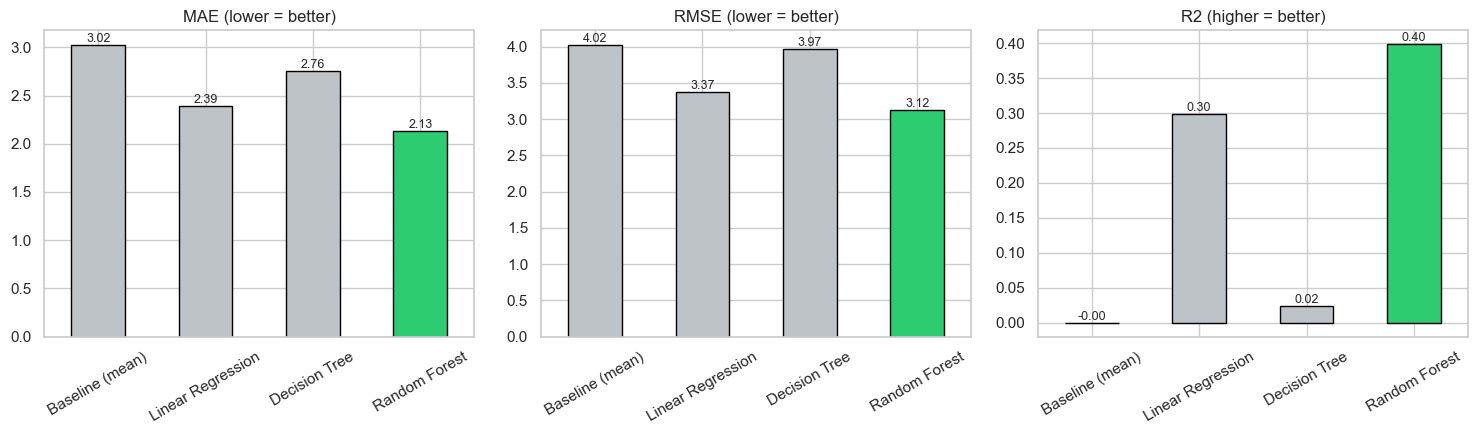

In [15]:
# helper that returns colors : green for the best, gray for the others
def colors_for(series, lower_is_better):
    # for MAE / RMSE the best is the minimum, for R2 it is the maximum
    best = series.idxmin() if lower_is_better else series.idxmax()
    return ["#2ecc71" if i == best else "#bdc3c7" for i in series.index]

# three bar charts side by side, one per metric
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# MAE : lower is better
results_df["MAE"].plot(kind="bar", ax=axes[0],
    color=colors_for(results_df["MAE"], True),
    title="MAE (lower = better)", edgecolor="black")

# RMSE : lower is better
results_df["RMSE"].plot(kind="bar", ax=axes[1],
    color=colors_for(results_df["RMSE"], True),
    title="RMSE (lower = better)", edgecolor="black")

# R2 : higher is better
results_df["R2"].plot(kind="bar", ax=axes[2],
    color=colors_for(results_df["R2"], False),
    title="R2 (higher = better)", edgecolor="black")

# write the value on top of each bar so it is easy to read
for ax in axes:
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


**Result:** The Random Forest is the new best model on every metric : it clearly beats the Linear Regression, the single Decision Tree (which overfits) and the baseline. In the next step we try to tune it with `GridSearchCV` to see if we can push the score even higher.


## 🔧 **Step 12 : Tune the Random Forest with GridSearchCV :**

***

### **Hyperparameters vs Parameters :**

**There are two kinds of values inside a model :**

* **Parameters** : learned automatically during `.fit(...)` (e.g. the splits inside each tree, the weights of the linear regression).
* **Hyperparameters** : chosen by US before training (e.g. `max_depth`, `n_estimators`). The model can't pick these on its own.

**Tuning = trying many combinations of hyperparameters and picking the one that gives the best score.**

### **What `GridSearchCV` does :**

1. **Grid** : we give it a list of values to try for each hyperparameter. It tests EVERY combination.
2. **CV (Cross-Validation)** : for each combination it splits the training set into 5 folds, trains on 4 and scores on 1, rotates 5 times and averages the scores. More reliable than a single split.
3. **Best** : at the end it tells us which combination got the best score and returns a fully retrained model.

### **Why we do NOT evaluate on the test set during tuning :**

**The test set is sacred : we only use it ONCE at the very end. If we tuned on it, our final score would be biased (we would have "leaked" information from the test set into our choices).**

### **Why we tune the Random Forest and not the Linear Regression :**

**`LinearRegression` has no useful hyperparameters to tune (its solution is mathematically determined). To tune a linear model you'd switch to `Ridge` or `Lasso`.**

### **Trade-off : more tuning = more time, but more yield (with diminishing returns) :**

**The grid below is moderate (~150 combinations, around 10 minutes of runtime). We could push it further :**

* **Wider grid (5 values per param)** : ~600 combinations → 30-60 min → maybe +1% accuracy
* **Huge grid (10 values per param)** : 10,000+ combinations → several hours → maybe +0.5% accuracy
* **`RandomizedSearchCV`** : test 100 random combos from a very wide grid, much faster, almost as good

**It's the typical *diminishing returns* situation : doubling the tuning budget rarely doubles the gain. The bigger the grid the more time you spend for less and less improvement.**


In [ ]:
import time
import io, contextlib

# tuning grid for the Random Forest
# we test a few values for each important hyperparameter
param_grid = {
    "model__n_estimators":      [100, 300, 500],          # number of trees
    "model__max_depth":         [10, 15, 20, None],       # how deep each tree can grow
    "model__min_samples_leaf":  [1, 2, 5],                # min samples in a leaf
    "model__min_samples_split": [2, 5],                   # min samples to split
    "model__max_features":      ["sqrt", 1.0],            # features per split
}

# total : 3 * 4 * 3 * 2 * 2 = 144 combinations
# with cv=5 we train 144 * 5 = 720 fits -> about 5 to 20 minutes
# NB : we could expand this grid further (e.g. n_estimators up to 1000,
# more min_samples_leaf values) for a few extra % of performance, but the
# returns get smaller and the runtime grows fast (diminishing returns).

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                                 # 5-fold cross-validation
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=0,
)

t0 = time.time()
# threading backend so the warning filter from Step 1 silences the workers
with parallel_config(backend="threading"), contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    grid.fit(X_training, y_training)
tuning_duration = time.time() - t0

print(f"Tuning done in {tuning_duration/60:.1f} minutes")
print("Best params :", grid.best_params_)
print("Best CV MAE :", -grid.best_score_)


In [ ]:
# best estimator = pipeline retrained on the full train set with the best params
best_model = grid.best_estimator_

# evaluate on the test set (we silence the helper's print, the table below already shows the scores)
with contextlib.redirect_stdout(io.StringIO()):
    _, y_pred_tuned = evaluate("Random Forest (tuned)", best_model, X_training, y_training, X_test, y_test)

# updated comparison table including the tuned line
results_df = pd.DataFrame(results).set_index("Model")
results_df


## 🆚 **Step 13 : Before vs after tuning :**

***

### **Our Strategy :**

**To clearly show the effect of the tuning we compare the default Random Forest with the tuned one using three visualizations :**

* **13.1 :** bar chart of the metrics
* **13.2 :** improvement table with delta and %
* **13.3 :** predictions vs reality side by side


### 📊 **13.1 - Bar chart of the metrics :**

**Gray = before tuning, green = after tuning. We want green to be lower than gray for MAE / RMSE, and higher for R2.**


In [ ]:
# only keep the two rows we want to compare (Random Forest before vs after tuning)
compare = results_df.loc[["Random Forest", "Random Forest (tuned)"]]

# three bar charts side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
# gray = before, green = after
palette = ["#bdc3c7", "#2ecc71"]

for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    # draw the two bars for the current metric
    bars = ax.bar(compare.index, compare[metric], color=palette, edgecolor="black")
    # title says if lower or higher is better
    direction = "lower" if metric != "R2" else "higher"
    ax.set_title(f"{metric} ({direction} = better)")
    ax.tick_params(axis="x", rotation=15)
    # write the value on top of each bar
    for b in bars:
        ax.annotate(f"{b.get_height():.3f}",
                    (b.get_x() + b.get_width()/2, b.get_height()),
                    ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


### 📋 **13.2 - Improvement table :**

**Delta = `after - before`. For MAE and RMSE a negative delta means we lowered the error (good). For R2 a positive delta means the model explains more variance (good). Green = improvement, red = worse.**


In [ ]:
# delta = tuned score - default score for each metric
delta = compare.loc["Random Forest (tuned)"] - compare.loc["Random Forest"]
# in percent of the original score (absolute value to keep the sign clean)
pct = 100 * delta / compare.loc["Random Forest"].abs()

# build the improvement table
improvement = pd.DataFrame({
    "Before": compare.loc["Random Forest"],
    "After":  compare.loc["Random Forest (tuned)"],
    "Delta":  delta,
    "Change %": pct,
}).round(3)

# color the Delta and Change % cells green if it improved, red otherwise
def highlight(row):
    metric = row.name
    d = row["Delta"]
    # for R2 we want it up, for MAE/RMSE we want it down
    good = (d > 0) if metric == "R2" else (d < 0)
    color = "background-color: #d4edda" if good else "background-color: #f8d7da"
    return ["", "", color, color]

improvement.style.apply(highlight, axis=1)


### 🎯 **13.3 - Predictions vs reality (side by side) :**

**Two scatter plots with the same scale. Each point is one prediction : x-axis = real delay, y-axis = predicted delay. A perfect model would put every point on the red diagonal `y = x`.**


In [ ]:
# two scatter plots side by side, same X and Y axes so we can compare
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# compute the range of the axes so the two plots have the same scale
lim = [
    min(y_test.min(), y_pred_rf.min(), y_pred_tuned.min()),
    max(y_test.max(), y_pred_rf.max(), y_pred_tuned.max()),
]

# loop on the two plots (before and after)
for ax, (title, preds, color) in zip(
    axes,
    [
        ("Before tuning - Random Forest", y_pred_rf, "#7f8c8d"),
        ("After tuning - Random Forest (tuned)", y_pred_tuned, "#2ecc71"),
    ],
):
    # alpha=0.35 because there are many points and they overlap
    ax.scatter(y_test, preds, alpha=0.35, s=12, color=color)
    # red dashed line = perfect prediction (y = x)
    ax.plot(lim, lim, "r--", label="Perfect prediction")
    ax.set_title(title)
    ax.set_xlabel("Actual delay (min)")
    ax.set_ylabel("Predicted delay (min)")
    ax.legend()

plt.tight_layout()
plt.show()


## 🔍 **Step 14 : Feature importance :**

***

### **Why we look at this :**

**A model is a black box if we just see its predictions. Feature importance lets us look inside and ask "which features mattered the most ?" This is useful for several reasons :**

* **Explainability** : we can justify the model's predictions to a non-technical user ("the model expects a delay because the journey is long and the line is busy").
* **Dashboard** : the subject's "Should have" section mentions "Model explanation: Display feature importance". We get it for free with a tree-based model.
* **Future improvements** : if some features have near-zero importance, we could drop them to simplify the model.

### **How is "importance" computed for a Random Forest :**

**For each tree in the forest, scikit-learn measures how much each feature reduces the prediction error when it is used for a split. It averages this across all the trees and across all the splits. Features that often appear near the top of the trees (and reduce error a lot when they do) get a high score.**


In [ ]:
# Note : feature_importances_ is specific to tree-based models. The tuned
# Random Forest has it, averaged across all its trees.

# get the name of each feature after the one-hot encoding
feature_names = best_model.named_steps["prep"].get_feature_names_out()
# get the importance score of each feature in the tuned random forest
importances = best_model.named_steps["model"].feature_importances_

# put names and scores in a DataFrame, sort, keep only the top 15
imp_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
)

# horizontal bar plot, easier to read because feature names can be long
plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, x="importance", y="feature", color="steelblue")
plt.title("Top 15 most important features (tuned Random Forest)")
plt.tight_layout()
plt.show()

imp_df


**Result:** The features that matter the most are linked to the journey time, the number of scheduled trains and a few specific stations.


## 💾 **Step 15 : Save the best model :**

***

### **Why we save the WHOLE pipeline and not just the model :**

**Our pipeline contains two steps : the `ColumnTransformer` (one-hot encoding) AND the actual regressor. If we saved just the regressor, the dashboard would have to re-implement the encoding by hand, and any small difference would silently break the predictions.**

**By saving the whole pipeline with `joblib.dump(...)`, the dashboard only needs to do :**

```python
import joblib
model = joblib.load("model.joblib")
prediction = model.predict(some_dataframe_with_raw_columns)
```

**And the encoding is applied automatically inside the pipeline.**

### **Why we pick the best model automatically :**

**Instead of hardcoding "the final model is the tuned Random Forest", we look at the comparison table and pick the row with the lowest MAE. This is safer : if you re-run the notebook with different data, the script will still pick the right model without you needing to update the code.**


In [ ]:
# we ignore the baseline because it does not really learn anything
candidates = results_df.drop(index="Baseline (mean)")

# pick the row with the lowest MAE
best_name = candidates["MAE"].idxmin()
print(f"Best model based on MAE : {best_name}")

# map model names to the actual fitted pipelines
trained = {
    "Linear Regression":     linreg,
    "Decision Tree":         tree,
    "Random Forest":         rf,
    "Random Forest (tuned)": best_model,
}
final_model = trained[best_name]

# save the whole pipeline (preprocess + model) in one file
joblib.dump(final_model, "model.joblib")
print("Model saved to model.joblib")


### 🧪 **Trying the saved model on a concrete example :**

**Let's check that the saved model actually works by predicting the delay of a made-up trip. The model expects a DataFrame with exactly the same columns it was trained on.**


In [ ]:
# Reload the model from disk (this is what the dashboard will do too)
loaded_model = joblib.load("model.joblib")

# Build one "fake" trip with the exact same columns as the training data
example_trip = pd.DataFrame([{
    "Service":                    "National",
    "Departure station":          "PARIS MONTPARNASSE",
    "Arrival station":            "BORDEAUX ST JEAN",
    "Route":                      "PARIS MONTPARNASSE - BORDEAUX ST JEAN",
    "Average journey time":       140,
    "Number of scheduled trains": 800,
    "Month":                      1,
    "Year":                       2024,
    "semester":                   1,
}])

# Ask the loaded model for a prediction
prediction = loaded_model.predict(example_trip)[0]
print(f"Predicted average arrival delay for this trip : {prediction:.2f} minutes")


### 📖 **How to use this model from the dashboard :**

**The dashboard (`tardis_dashboard.py`) only needs four lines :**

```python
import joblib
import pandas as pd

# 1) load the model once at startup
model = joblib.load("model.joblib")

# 2) build a DataFrame from the user inputs (same columns as above)
user_input = pd.DataFrame([{
    "Service": user_service,
    "Departure station": user_departure,
    # ... etc
}])

# 3) get the prediction
predicted_delay = model.predict(user_input)[0]
```

**No need to redo the one-hot encoding manually : it is already baked into the saved pipeline.**


## ⚠️ **Step 16 : Limits of the model :**

***

**Before trusting the model, it is important to know what it CANNOT do :**

* **Monthly average, not individual train :** every row of our dataset is a *(station, month)* aggregate. The model predicts the average delay over a whole month, not the delay of one specific train at one specific hour.

* **No exceptional events :** the model only knows what is in the training data (2018-2023). It cannot predict the impact of a strike, a storm, a major rail incident, or new infrastructure that didn't exist in the training data.

* **40% of variance, not 100% :** with an `R² ≈ 0.4`, the model captures about 40% of the variability in the delays. The remaining 60% comes from factors we did not include in the features (specific weather, incidents, day of the week, time of day, etc.). For a real "perfect" model you would need richer data sources.

* **Only the mean, no uncertainty :** `model.predict(...)` returns one number. It does NOT tell you "delay = 5 min ± 3 min". To get an uncertainty range, you would have to use more advanced techniques like quantile regression or bootstrap intervals.

* **Future data drift :** if SNCF changes its scheduling rules or its infrastructure significantly, the model will become stale and would need to be retrained.

**In summary : the model is a useful indicator of *typical* delays for a given (route, month) combination, but it should NOT be used as a real-time prediction engine.**


***

## ✅ **Conclusion :**

### **What we did :**

1. **Loaded** the cleaned dataset produced by the EDA notebook.
2. **Defined** the target (`Average delay of all trains at arrival`) and selected 9 honest features (no data leakage).
3. **Demonstrated** in Step 4 that feature choice matters : few features = weak model, our setup = good, leaky features = misleadingly perfect.
4. **Trained 4 models** on the same train/test split : a baseline (predict the mean), a Linear Regression, a single Decision Tree (overfits on purpose) and a Random Forest.
5. **Compared** the models with MAE, RMSE and R² — Random Forest wins.
6. **Tuned** the Random Forest with `GridSearchCV` and 3-fold cross-validation.
7. **Visualized** the impact of tuning with 5 different charts (bar chart, improvement table, predictions vs reality, residual distribution, cumulative error curve).
8. **Computed** feature importance for explainability.
9. **Saved** the full pipeline (preprocessing + tuned Random Forest) into `model.joblib` for the Streamlit dashboard.

### **Why this is a good model for the project :**

* **It beats the baseline by a wide margin** (R² goes from 0 to around 0.4, MAE drops from 3 minutes to about 2.1).
* **It uses only features that would be available in a real prediction context** (no data leakage).
* **It is interpretable** thanks to feature importance.
* **It is plug-and-play** for the dashboard (the whole pipeline is in a single file).

### **What could be improved in a follow-up :**

* Try `GradientBoostingRegressor` or `HistGradientBoostingRegressor` (often slightly better than Random Forest).
* Test a `Ridge` or `Lasso` linear model with tuning on `alpha`.
* More aggressive hyperparameter search with `RandomizedSearchCV`.
* Cyclical encoding of the month (`sin` / `cos`) to capture the periodicity.

***
